# 06 - Text CNN: Clasificación de Sentimientos

Este notebook aplica un **Red Neuronal Convolucional (1D)** para clasificar el sentimiento de posts en redes sociales usando n-gramas.

El modelo se define en models/cnn_text.py y se carga desde este notebook.

**Dataset:** SocialBuzz Sentiment Analytics (732 muestras)

**Target:** Sentimiento agrupado en 3 clases: Positivo, Neutro, Negativo

**Características:** Embeddings de palabras (secuencia tokenizada, longitud 50)

**Corrección:** Se aplica class weights y L2 regularization/dropout para evitar overfitting.

## 0) Instalación e importación de librerías

In [1]:
import sys
import os

try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'kagglehub', '-q'])
    import kagglehub

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    os.makedirs('models', exist_ok=True)
    model_code = '''import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        num_classes: int = 3,
        num_filters: int = 64,
        filter_sizes: list = [2, 3, 4],
        dropout: float = 0.6,
        pad_idx: int = 0
    ):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=fs
            ) for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(x)
        embedded = embedded.permute(0, 2, 1)
        conved = [torch.nn.functional.relu(conv(embedded)) for conv in self.convs]
        pooled = [torch.nn.functional.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

def build_model(
    vocab_size: int,
    embed_dim: int = 64,
    num_classes: int = 3,
    num_filters: int = 64,
    filter_sizes: list = [2, 3, 4],
    dropout: float = 0.6,
    pad_idx: int = 0
) -> TextCNN:
    return TextCNN(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_classes=num_classes,
        num_filters=num_filters,
        filter_sizes=filter_sizes,
        dropout=dropout,
        pad_idx=pad_idx
    )
    '''
    with open('models/__init__.py', 'w') as f:
        f.write('')
    with open('models/cnn_text.py', 'w') as f:
        f.write(model_code)
    sys.path.insert(0, '.')
    print('Archivo models/cnn_text.py creado para Colab.')
else:
    current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
    sys.path.insert(0, current_dir)
    print(f'Ejecutando localmente. Path: {current_dir}')

Archivo models/cnn_text.py creado para Colab.


In [2]:
import copy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, roc_curve, auc
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from models.cnn_text import TextCNN, build_model

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Librerías importadas correctamente.')

Device: cpu
Librerías importadas correctamente.


## 1) Carga de datos

In [3]:
path = kagglehub.dataset_download('eshummalik/socialbuzz-sentiment-analytics')
file_path = os.path.join(path, 'sentimentdataset.csv')
df = pd.read_csv(file_path)

print(f'Shape: {df.shape}')
df.head(3)

100%|██████████| 50.9k/50.9k [00:00<00:00, 14.6MB/s]

Extracting files...
Shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


## 2) Preprocesado e Ingeniería de Características

In [4]:
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()

POSITIVE_EMOTIONS = {
    'Joy', 'Positive', 'Happiness', 'Happy', 'Excitement', 'Elation', 'Euphoria',
    'Love', 'Gratitude', 'Contentment', 'Optimism', 'Hope', 'Hopeful', 'Satisfaction',
    'Pride', 'Proud', 'Amusement', 'Awe', 'Inspiration', 'Inspired', 'Enthusiasm',
    'Confidence', 'Confident', 'Empowerment', 'Freedom', 'Courage', 'Determination',
    'Accomplishment', 'Celebration', 'Serenity', 'Tranquility', 'Peace', 'Calmness',
    'Positivity', 'Blessed', 'Warmth', 'Heartwarming', 'Tenderness', 'Affection',
    'Admiration', 'Adoration', 'Amazement', 'Wonder', 'Wonderment', 'Enchantment',
    'Captivation', 'Marvel', 'Charm', 'Playful', 'PlayfulJoy', 'FestiveJoy',
    'JoyfulReunion', 'Overjoyed', 'Ecstasy', 'Triumph', 'Success', 'Fulfillment',
    'Appreciation', 'Relieved', 'Relief', 'Kindness', 'Kind',
    'Compassion', 'Compassionate', 'Sympathy', 'Empathetic', 'Friendship', 'Romance',
    'Connection', 'Harmony', 'Radiance', 'Zest', 'Energy', 'Vibrancy', 'Spark',
    'Breakthrough', 'Motivation', 'Resilience', 'Adventure', 'Exploration',
    'Curiosity', 'Imagination', 'Creativity', 'Creative Inspiration', 'ArtisticBurst',
    'Grateful', 'Rejuvenation', 'Journey', 'Mindfulness', 'Solace', 'Touched',
    'Acceptance', 'Bittersweet', 'Whimsy', 'Free-spirited',
    'Dazzle', 'Hypnotic', 'Mesmerizing', 'Iconic', 'Melodic', 'Grandeur',
    'Reverence', 'Anticipation', 'Thrill', 'Thrilling Journey', 'Immersion',
    'Engagement', 'Colorful', 'Elegance', 'Runway Creativity',
    'CulinaryOdyssey', 'Culinary Adventure', 'Joy in Baking', 'Adrenaline',
    "Nature's Beauty", "Ocean's Freedom", 'Celestial Wonder', 'Envisioning History',
    'Winter Magic', 'Whispers of the Past', 'Ruins', 'Enjoyment', 'Intrigue',
    'DreamChaser', 'InnerJourney', 'Arousal',
}

NEGATIVE_EMOTIONS = {
    'Negative', 'Sadness', 'Sad', 'Anger', 'Fear', 'Fearful', 'Despair', 'Desperation',
    'Grief', 'Sorrow', 'Heartbreak', 'Heartache', 'LostLove', 'Loss', 'Loneliness',
    'Isolation', 'Disappointment', 'Disappointed', 'Regret', 'Guilt', 'Shame',
    'Frustration', 'Frustrated', 'Hate', 'Resentment', 'Envy', 'Envious',
    'Jealousy', 'Jealous', 'Disgust', 'Betrayal', 'Bitterness', 'Bitter', 'Bad',
    'Desolation', 'Darkness', 'Suffering', 'Helplessness', 'Devastated', 'Overwhelmed',
    'Anxiety', 'Apprehensive', 'Pressure', 'Exhaustion', 'Numbness', 'Melancholy',
    'Pensive', 'Obstacle', 'Miscalculation', 'Intimidation', 'Dismissive',
    'EmotionalStorm', 'Mischievous',
}

NEUTRAL_EMOTIONS = {
    'Neutral', 'Indifference', 'Nostalgia', 'Reflection', 'Contemplation',
    'Ambivalence', 'Surprise', 'Confusion', 'Suspense', 'Yearning', 'Solitude',
    'Coziness', 'Embarrassed', 'Embarrassment',
}

def map_sentiment(sent):
    if sent in POSITIVE_EMOTIONS: return 'Positivo'
    if sent in NEGATIVE_EMOTIONS: return 'Negativo'
    if sent in NEUTRAL_EMOTIONS: return 'Neutro'

    s_lower = sent.lower()
    for kw in ['joy', 'happy', 'love', 'hope', 'good', 'great', 'excit', 'wonder', 'posit', 'glad', 'cheer', 'bright', 'amaz', 'thrill', 'bliss']:
        if kw in s_lower: return 'Positivo'
    for kw in ['sad', 'bad', 'hate', 'fear', 'angry', 'angr', 'grief', 'depress', 'negat', 'despair', 'pain', 'sorrow', 'hurt', 'rage', 'bitter']:
        if kw in s_lower: return 'Negativo'
    return 'Neutro'

df['sentiment_group'] = df['Sentiment'].apply(map_sentiment)
print('Distribución de clases:')
print(df['sentiment_group'].value_counts())

Distribución de clases:
sentiment_group
Positivo    474
Negativo    175
Neutro       83
Name: count, dtype: int64


In [6]:
def simple_tokenize(text):
    # Convertir a minúsculas y mantener palabras y emojis (caracteres no-ASCII)
    tokens = re.findall(r'\w+|[^\x00-\x7f]+', text.lower())
    return tokens

le = LabelEncoder()
y = le.fit_transform(df['sentiment_group'])
print(f'Clases: {le.classes_}')

texts = df['Text'].values
texts_train = df_train['Text'].values
texts_val = df_val['Text'].values
texts_test = df_test['Text'].values

# División 70/15/15
df_train, df_temp, y_train, y_temp = train_test_split(
    df, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
df_val, df_test, y_val, y_test = train_test_split(
    df_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

# Construir vocabulario a partir del train
VOCAB_SIZE = 3000
PAD_IDX = 0
UNK_IDX = 1

word_counter = Counter()
for text in texts_train:
    word_counter.update(simple_tokenize(text))

most_common = word_counter.most_common(VOCAB_SIZE - 2)
word2idx = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX
word2idx['<UNK>'] = UNK_IDX

actual_vocab_size = len(word2idx)
print(f'Vocabulario: {actual_vocab_size} palabras')

Clases: ['Negativo' 'Neutro' 'Positivo']
Train: 512 | Val: 110 | Test: 110
Vocabulario: 2039 palabras


In [7]:
MAX_SEQ_LEN = 50

def encode_text(text, word2idx, max_len):
    tokens = simple_tokenize(text)
    indices = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    if len(indices) < max_len:
        indices += [PAD_IDX] * (max_len - len(indices))
    return indices

X_train_seq = np.array([encode_text(t, word2idx, MAX_SEQ_LEN) for t in texts_train])
X_val_seq   = np.array([encode_text(t, word2idx, MAX_SEQ_LEN) for t in texts_val])
X_test_seq  = np.array([encode_text(t, word2idx, MAX_SEQ_LEN) for t in texts_test])

print(f'Shape X_train: {X_train_seq.shape}')
print(f'Shape X_val:   {X_val_seq.shape}')
print(f'Shape X_test:  {X_test_seq.shape}')

# Pesos de clase para balanceo
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Pesos de clase: {dict(zip(le.classes_, weights))}')

Shape X_train: (512, 50)
Shape X_val:   (110, 50)
Shape X_test:  (110, 50)
Pesos de clase: {'Negativo': np.float64(1.3989071038251366), 'Neutro': np.float64(2.942528735632184), 'Positivo': np.float64(0.5140562248995983)}


## 3) Construcción del modelo (TextCNN)

In [8]:
EMBED_DIM   = 32
NUM_CLASSES = len(le.classes_)
NUM_FILTERS = 32
FILTER_SIZES = [2, 3, 4]
DROPOUT     = 0.6

model = build_model(
    vocab_size=actual_vocab_size,
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
)
model = model.to(device)

n_params = model.count_parameters()
print(model)
print(f'\nNúmero total de parámetros entrenables: {n_params:,}')


TextCNN(
  (embedding): Embedding(2039, 32, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(32, 32, kernel_size=(2,), stride=(1,))
    (1): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
    (2): Conv1d(32, 32, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.6, inplace=False)
  (fc): Linear(in_features=96, out_features=3, bias=True)
)

Número total de parámetros entrenables: 74,851


In [9]:
def to_tensors_seq(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.long),
        torch.tensor(y, dtype=torch.long)
    )

BATCH_SIZE = 32

train_dataset = to_tensors_seq(X_train_seq, y_train)
val_dataset   = to_tensors_seq(X_val_seq,   y_val)
test_dataset  = to_tensors_seq(X_test_seq,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Batches en train: {len(train_loader)}')

Batches en train: 16


## 4) Entrenamiento

In [10]:
EPOCHS    = 150
LR        = 0.0003
PATIENCE  = 6

# Class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)
# L2
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss  = float('inf')
best_state     = None
epochs_no_imp  = 0

print(f'Entrenando por max. {EPOCHS} epocas (early stopping patience={PATIENCE})...\n')
for epoch in range(1, EPOCHS + 1):

    # --- Training ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += len(y_batch)

    # --- Validation ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs      = model(X_batch)
            loss         = criterion(outputs, y_batch)
            val_loss_sum += loss.item() * len(y_batch)
            preds         = outputs.argmax(dim=1)
            val_correct  += (preds == y_batch).sum().item()
            val_total    += len(y_batch)

    t_loss = train_loss   / train_total
    v_loss = val_loss_sum / val_total
    t_acc  = train_correct / train_total
    v_acc  = val_correct   / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(v_loss)

    # Early stopping sobre validation loss
    if v_loss < best_val_loss - 1e-4:
        best_val_loss = v_loss
        import copy
        best_state    = copy.deepcopy(model.state_dict())
        epochs_no_imp = 0
    else:
        epochs_no_imp += 1

    if epochs_no_imp >= PATIENCE:
        print(f'Early stopping en epoca {epoch} (sin mejora en {PATIENCE} epocas).')
        break

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoca {epoch:3d}/{EPOCHS}  |  '
              f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  |  '
              f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

# Restaurar el mejor modelo
if best_state is not None:
    model.load_state_dict(best_state)
print(f'\nEntrenamiento completado. Mejor Val Loss: {best_val_loss:.4f}')

Entrenando por max. 150 epocas (early stopping patience=6)...

Epoca   1/150  |  Train Loss: 1.4231  Train Acc: 0.4629  |  Val Loss: 1.1962  Val Acc: 0.5000
Epoca  10/150  |  Train Loss: 1.0717  Train Acc: 0.4180  |  Val Loss: 1.1236  Val Acc: 0.3182
Epoca  20/150  |  Train Loss: 1.0624  Train Acc: 0.4512  |  Val Loss: 1.1082  Val Acc: 0.4273
Epoca  30/150  |  Train Loss: 0.9501  Train Acc: 0.5723  |  Val Loss: 1.0929  Val Acc: 0.4545
Epoca  40/150  |  Train Loss: 0.8481  Train Acc: 0.6211  |  Val Loss: 1.0745  Val Acc: 0.4909
Epoca  50/150  |  Train Loss: 0.7941  Train Acc: 0.6719  |  Val Loss: 1.0611  Val Acc: 0.5000
Epoca  60/150  |  Train Loss: 0.7356  Train Acc: 0.7324  |  Val Loss: 1.0509  Val Acc: 0.5727
Epoca  70/150  |  Train Loss: 0.7073  Train Acc: 0.7090  |  Val Loss: 1.0397  Val Acc: 0.5636
Epoca  80/150  |  Train Loss: 0.6666  Train Acc: 0.7656  |  Val Loss: 1.0336  Val Acc: 0.5636
Epoca  90/150  |  Train Loss: 0.6396  Train Acc: 0.8027  |  Val Loss: 1.0333  Val Acc: 0.56

## 5) Curvas de entrenamiento

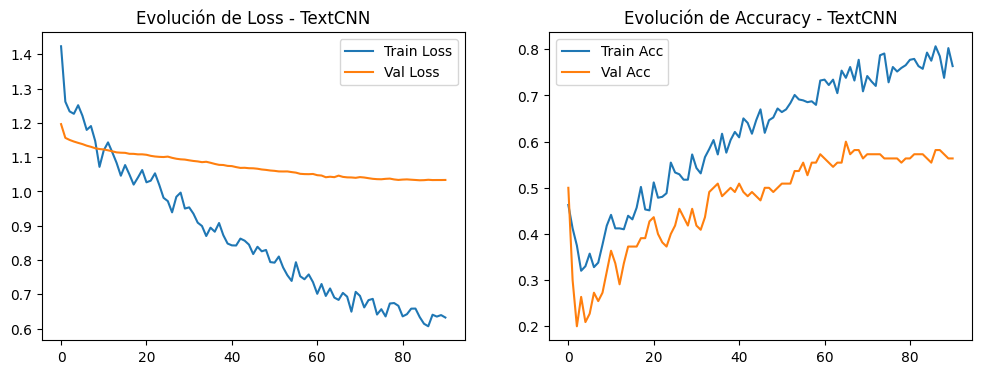

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Evolución de Loss - TextCNN')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Evolución de Accuracy - TextCNN')
plt.legend()
plt.show()

## 6) Evaluación

In [12]:
def evaluate_model(model, loader, split_name, class_names, device):
    """Evaluación completa con todas las métricas."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc  = accuracy_score(all_labels, all_preds)
    f1_macro    = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    precision_macro = precision_score(all_labels, all_preds, average='macro')
    recall_macro    = recall_score(all_labels, all_preds, average='macro')
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc   = matthews_corrcoef(all_labels, all_preds)

    try:
        auc_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_ovr = float('nan')

    print(f'\n{"="*60}')
    print(f'  {split_name}')
    print(f'{"="*60}')
    print(f'  Accuracy           : {acc:.4f}')
    print(f'  Precision (macro)  : {precision_macro:.4f}')
    print(f'  Recall (macro)     : {recall_macro:.4f}')
    print(f'  F1-Score (macro)   : {f1_macro:.4f}')
    print(f'  F1-Score (weighted): {f1_weighted:.4f}')
    print(f'  Cohen\'s Kappa      : {kappa:.4f}')
    print(f'  MCC                : {mcc:.4f}')
    print(f'  AUC-ROC (OvR macro): {auc_ovr:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    return {
        'acc': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'precision': precision_macro, 'recall': recall_macro,
        'kappa': kappa, 'mcc': mcc, 'auc_roc': auc_ovr,
        'labels': all_labels, 'preds': all_preds, 'probs': all_probs
    }

class_names = le.classes_

results_train = evaluate_model(model, train_loader, 'TRAIN',      class_names, device)
results_val   = evaluate_model(model, val_loader,   'VALIDACIÓN', class_names, device)
results_test  = evaluate_model(model, test_loader,  'TEST',       class_names, device)

print(f'| TextCNN | {n_params:,} | {results_train["acc"]:.4f} | {results_val["acc"]:.4f} | {results_test["acc"]:.4f} | {results_train["f1_macro"]:.4f} | {results_val["f1_macro"]:.4f} | {results_test["f1_macro"]:.4f} |')



  TRAIN
  Accuracy           : 0.9766
  Precision (macro)  : 0.9545
  Recall (macro)     : 0.9862
  F1-Score (macro)   : 0.9694
  F1-Score (weighted): 0.9768
  Cohen's Kappa      : 0.9549
  MCC                : 0.9556
  AUC-ROC (OvR macro): 0.9996

  Classification Report:
              precision    recall  f1-score   support

    Negativo     0.9603    0.9918    0.9758       122
      Neutro     0.9062    1.0000    0.9508        58
    Positivo     0.9969    0.9669    0.9817       332

    accuracy                         0.9766       512
   macro avg     0.9545    0.9862    0.9694       512
weighted avg     0.9779    0.9766    0.9768       512


  VALIDACIÓN
  Accuracy           : 0.5636
  Precision (macro)  : 0.5048
  Recall (macro)     : 0.5468
  F1-Score (macro)   : 0.5063
  F1-Score (weighted): 0.5837
  Cohen's Kappa      : 0.2691
  MCC                : 0.2845
  AUC-ROC (OvR macro): 0.7207

  Classification Report:
              precision    recall  f1-score   support

    Negat

## 7) Gráficos extra

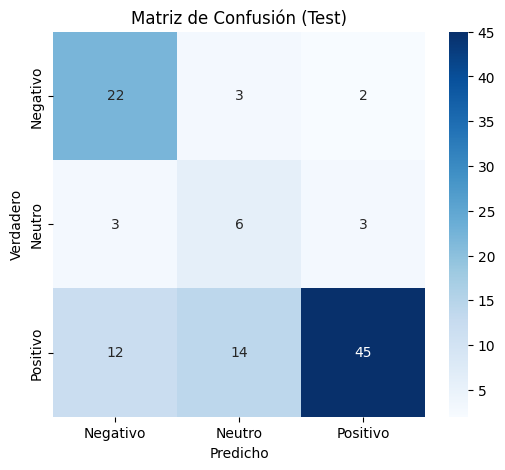

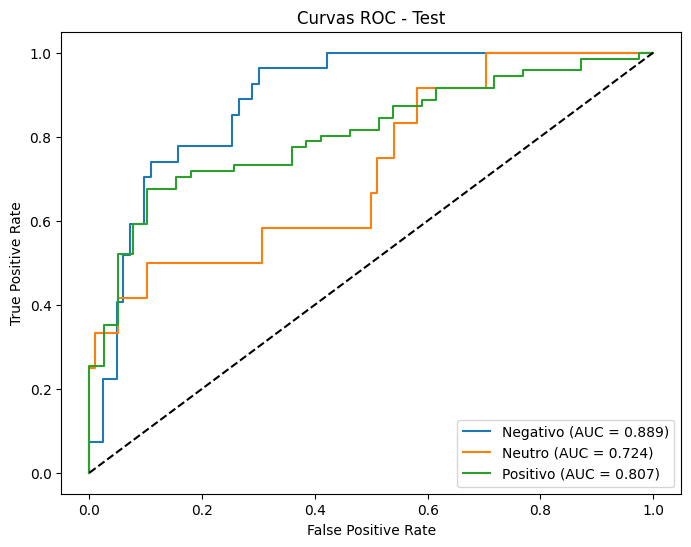

In [13]:
# Confusion Matrix Test
y_true = results_test["labels"]
y_pred = results_test["preds"]
y_probs = results_test["probs"]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión (Test)')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.show()

# ROC
plt.figure(figsize=(8,6))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(np.array(y_true) == i, y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.title('Curvas ROC - Test')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


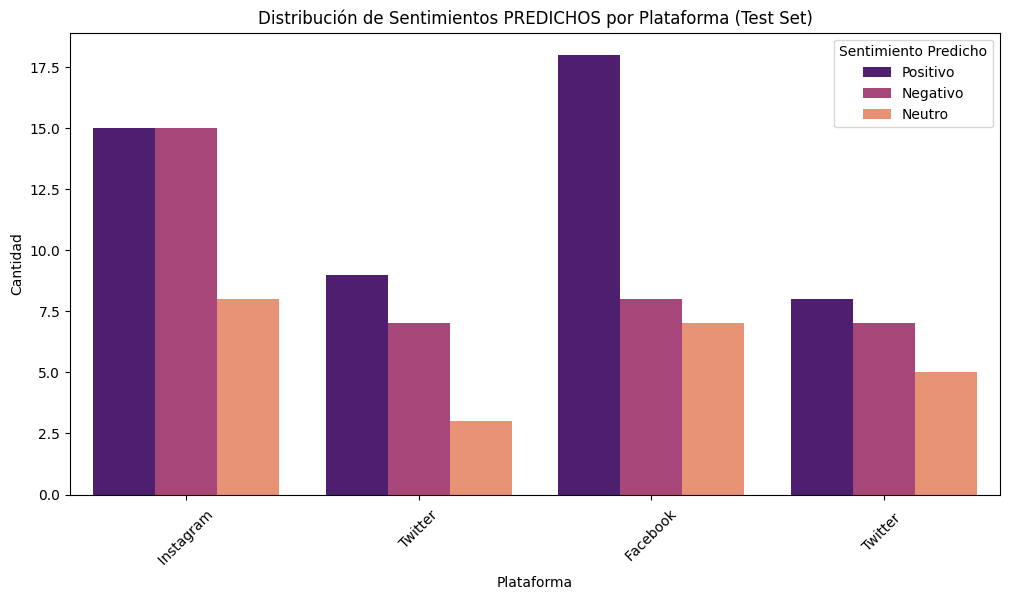

In [14]:
# Visualización: Sentimientos Predichos por Plataforma (Post-entrenamiento)
# Mapear predicciones numéricas a nombres de clases
test_preds_names = [le.classes_[p] for p in results_test['preds']]

# Crear un DataFrame temporal para la visualización
viz_df = (X_test_df if 'X_test_df' in locals() else df_test).copy()
viz_df['Predicted_Sentiment'] = test_preds_names

plt.figure(figsize=(12, 6))
sns.countplot(data=viz_df, x='Platform', hue='Predicted_Sentiment', palette='magma')
plt.title('Distribución de Sentimientos PREDICHOS por Plataforma (Test Set)')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(title='Sentimiento Predicho')
plt.show()